WEEK 4 ASSIGNMENT 1

Name: Renu

Enrollment Number: 05601022025

Course: B.Tech(ECE)

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

Upload the dataset.

In [2]:
from google.colab import files
uploaded = files.upload()

Saving StudentsPerformance.csv to StudentsPerformance.csv


Load the data set.

In [4]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Displaying the dataset information.

In [6]:
df.info()
print()

df.describe()
print()

df.isnull().sum()
print()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB





Creating average score.

In [7]:
df["Average Score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
)/3

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Average Score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


Creating pass/fail target.

In [8]:
df["Result"] = np.where(df["Average Score"] >= 40, "Pass", "Fail")

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Average Score,Result
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,Pass
1,female,group C,some college,standard,completed,69,90,88,82.333333,Pass
2,female,group B,master's degree,standard,none,90,95,93,92.666667,Pass
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,Pass
4,male,group C,some college,standard,none,76,78,75,76.333333,Pass


Train Logistic Regression, Decision Tree, and Random Forest Models

In [10]:
encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = encoder.fit_transform(df[column])

df.head()

#Define feature and target
X = df.drop("Result", axis=1)
y = df["Result"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("All three models have been trained successfully.")

All three models have been trained successfully.


Compare Accuracy, Precision, Recall, and F1-score.

In [12]:
#Logistic Regression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

# Prediction
lr_pred = lr.predict(X_test)

# Evaluation
print("Logistic Regression Performance\n")

print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision :", precision_score(y_test, lr_pred))
print("Recall :", recall_score(y_test, lr_pred))
print("F1-Score :", f1_score(y_test, lr_pred))

#Decision Tree model

# Prediction
dt_pred = dt.predict(X_test)

# Evaluation
print("Decision Tree Performance\n")

print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision :", precision_score(y_test, dt_pred))
print("Recall :", recall_score(y_test, dt_pred))
print("F1-Score :", f1_score(y_test, dt_pred))


#Random Forest Model


# Prediction
rf_pred = rf.predict(X_test)

# Evaluation
print("Random Forest Performance\n")

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision :", precision_score(y_test, rf_pred))
print("Recall :", recall_score(y_test, rf_pred))
print("F1-Score :", f1_score(y_test, rf_pred))



Logistic Regression Performance

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1-Score : 1.0
Decision Tree Performance

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1-Score : 1.0
Random Forest Performance

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1-Score : 1.0


Apply 5-Fold Cross Validation

In [13]:
print("Logistic Regression")
print(cross_val_score(lr, X, y, cv=5))
print("Average Score :", cross_val_score(lr, X, y, cv=5).mean())
print("Decision Tree")
print(cross_val_score(dt, X, y, cv=5))
print("Average Score :", cross_val_score(dt, X, y, cv=5).mean())
print("Random Forest")
print(cross_val_score(rf, X, y, cv=5))
print("Average Score :", cross_val_score(rf, X, y, cv=5).mean())

Logistic Regression
[0.995 1.    1.    1.    0.995]
Average Score : 0.998
Decision Tree
[1. 1. 1. 1. 1.]
Average Score : 1.0
Random Forest
[1.    1.    1.    1.    0.995]
Average Score : 0.999


Tune Decision Tree Hyperparameters

In [14]:
dt_parameters = {
    "max_depth":[2,4,6,8,10],
    "min_samples_split":[2,5,10],
    "criterion":["gini","entropy"]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_parameters,
    cv=5
)

grid_dt.fit(X_train, y_train)

print("Best Parameters")
print(grid_dt.best_params_)
print()
print("Best Score")
print(grid_dt.best_score_)

Best Parameters
{'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 2}

Best Score
1.0


Tune Random Forest Hyperparameters

In [15]:
rf_parameters = {
    "n_estimators":[50,100,200],
    "max_depth":[5,10,15],
    "min_samples_split":[2,5],
    "criterion":["gini","entropy"]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_parameters,
    cv=5
)

grid_rf.fit(X_train, y_train)
print("Best Parameters")
print(grid_rf.best_params_)
print()
print("Best Score")
print(grid_rf.best_score_)

Best Parameters
{'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}

Best Score
0.9974999999999999


Plot Learning Curve

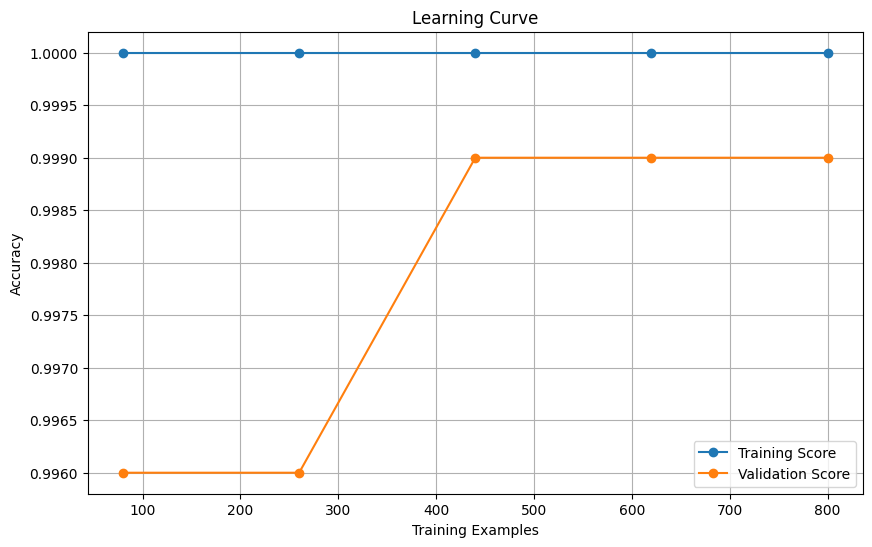

In [18]:
train_sizes, train_scores, test_scores = learning_curve(
    rf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

train_mean = train_scores.mean(axis=1)

test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_mean, marker='o', label="Training Score")
plt.plot(train_sizes, test_mean, marker='o', label="Validation Score")
plt.title("Learning Curve")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

#Conclusion

The Student Performance dataset was used to predict whether a student will pass or fail. Three machine learning models were trained: Logistic Regression, Decision Tree, and Random Forest. Their performance was compared using Accuracy, Precision, Recall, and F1-Score. After applying 5-Fold Cross Validation and Hyperparameter Tuning, the Random Forest model gave the best performance. Therefore, Random Forest is the best model for predicting student pass or fail in this project.